<a href="https://colab.research.google.com/github/DrFaus/Estadistica/blob/main/RegresionLinealSimple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión lineal simple y correlación

En la práctica y en la vida cotidiana, es común analizar la relación entre dos variables. Por ejemplo, aunque sabemos que el peso de una persona depende de múltiples factores, la estatura es uno de ellos. En este caso, el peso y la estatura pueden considerarse como variables, donde una actúa como variable dependiente y la otra como variable independiente.

De manera similar, el desempeño académico de un estudiante está influenciado por diversos factores; entre ellos, el tiempo de estudio. Por ello, es posible analizar la relación entre el tiempo dedicado al estudio y las calificaciones obtenidas, considerando nuevamente una variable dependiente y una independiente.

Un primer acercamiento al estudio de la relación entre dos variables puede realizarse mediante un modelo lineal. Su forma general es:

$$Y=\beta_0+\beta_1X$$

donde $\beta_0$ representa la intersección (o intercepto) y $\beta_1$ la pendiente de la recta.

En algunos casos, esta relación puede ser determinista. Un modelo es determinista cuando no existen componentes aleatorios dentro de su estructura.

Por ejemplo, si tienes un trabajo en el que te pagan \\$200 por cada hora trabajada y no existe ningún tipo de comisión o variación, el modelo que describe tus ganancias es:

$$Y=200X$$

donde $Y$ representa las ganancias y $X$ el número de horas trabajadas. En este caso, se trata de un modelo determinista sin intercepto.

También podría darse el caso de un trabajo con un sueldo base de \\$300 más \\$180 por cada hora trabajada. En ese caso, el modelo sería:

$$Y=300+180X$$

donde ahora se tiene un modelo determinista con intercepto.

Los fenómenos deterministas que pueden describirse mediante modelos lineales suelen ser simples e intuitivos, y su ajuste no requiere un alto rigor matemático ni un análisis profundo de conceptos estadísticos.

El problema surge cuando el fenómeno no es determinista. Por ejemplo, si consideramos a una persona que percibe comisiones dentro de sus ingresos, dichas comisiones introducen un componente aleatorio. En consecuencia, el fenómeno deja de ser determinista y pasa a ser estocástico.

Siguiendo con este ejemplo, el número de horas trabajadas continúa siendo un factor importante en el modelo que describe las ganancias de esta persona. Sin embargo, ahora se observa variabilidad en los ingresos: es posible que trabaje 5 horas en un día y gane \\$1,000; en otro día, trabajando también 5 horas, gane \\$1,200; y en un tercer día, con las mismas 5 horas de trabajo, obtenga \\$900.

Hay factores externos que no se pueden modelar; en este ejemplo, podrían ser la suerte, la época del año, la actitud de la persona hacia sus clientes, entre otros. Todos estos elementos influyen en las ganancias, pero no están explícitamente incluidos en el modelo.

Esta variabilidad se agrupa en un término aleatorio, comúnmente denotado como $\varepsilon$, el cual representa el efecto conjunto de todos aquellos factores no observados o no considerados. De esta manera, el modelo lineal se expresa como:

$$Y=\beta_0+\beta_1X+\varepsilon $$

donde $\varepsilon$ captura las desviaciones entre los valores observados y los valores predichos por el modelo. En otras palabras, $\varepsilon$ representa todos esos factores que intervienen pero que no podemos medir o no nos interesa medir, por lo que este término se deja fuera del modelo funcional.



## Gráfico de dispersión

La primera herramienta que utilizamos para hacer un análisis de correlación lineal es el gráfico de dispersión. Para esto, tenemos que haber identificado la variable independiente ($X$) y la variable dependiente ($Y$). Veamos el siguiente ejemplo:

En un hogar se quiere estimar el consumo de energía. Se ha identificado que cuando la temperatura aumenta, se utilizan más aparatos como ventiladores o aire acondicionado, por lo que se han recolectado los siguientes datos:

| Temperatura (°C) | Consumo (kWh) |
|------------------|---------------|
| 20               | 21            |
| 21               | 24            |
| 25               | 26            |
| 28               | 28            |
| 28               | 30            |
| 30               | 34            |
| 31               | 35            |
| 33               | 38            |

En este caso, se puede entender que el consumo depende en buena parte de la temperatura ambiente. Sin embargo, no es el único factor. También puede influir la humedad (que cambia la sensación térmica), si hay visitas (lo que puede requerir que más aparatos funcionen simultáneamente), el tiempo que las personas pasan en el interior del hogar, así como los hábitos de consumo de cada familia.

Todos estos factores no siempre son observables o cuantificables, por lo que no se incorporan explícitamente en el modelo. En consecuencia, su efecto se agrupa en un término aleatorio, lo que introduce variabilidad en el consumo incluso cuando la temperatura permanece constante. Ese término es $\varepsilon$.

Entonces estamos de acuerdo en que $X$ es la temperatura y $Y$ es el consumo de energía. Usando Python creamos las asignaciones de la siguiente manera:

In [2]:
# Importamos la paquetería numpy y le damos el pseudónimo np
import numpy as np

# Variable independiente (temperatura)
X = np.array([20, 21, 25, 28, 28, 30, 31, 33])

# Variable dependiente (consumo de energía)
Y = np.array([21, 24, 26, 28, 30, 34, 35, 38])

Y creamos el gráfico de dispersión de la siguiente manera:

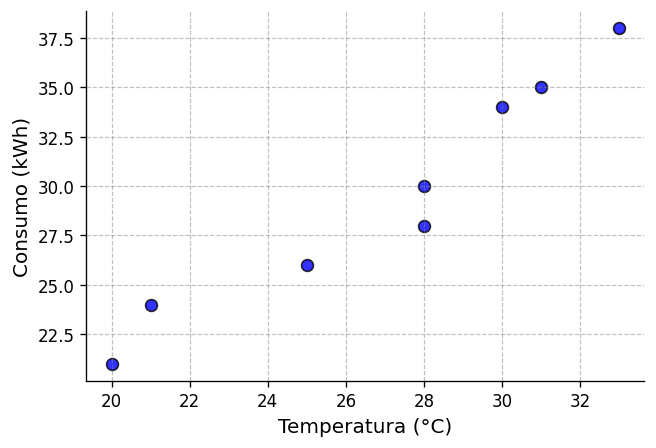

In [6]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Temperatura (°C)', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Consumo (kWh)', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)


El gráfico de dispersión es una de las primeras herramientas utilizadas en el análisis de la relación entre dos variables, ya que permite visualizar de manera clara su comportamiento conjunto. Como se observa en el gráfico, los datos presentan un patrón aproximadamente lineal, como si los puntos tendieran a alinearse en torno a una recta que no podemos ver.

Este comportamiento proporciona un indicio importante de la existencia de una relación entre las variables. Sin embargo, es fundamental recordar que la correlación no implica causalidad.

## Coeficiente de correlación

De manera complementaria al gráfico de dispersión, se utiliza el coeficiente de correlación. Este es un número adimensional que toma valores en el intervalo $-1 \leq r \leq 1$ y mide el grado de relación lineal entre dos variables.

Si $r = -1$, indica una relación lineal perfectamente decreciente (si aumneta $X$ disminuye $Y$); mientras que si $r = 1$, indica una relación lineal perfectamente creciente (si aumenta $X$ también aumenta $Y$). En ambos casos, la relación es determinista y los datos se encuentran exactamente sobre una recta.

En la mayoría de los casos, el coeficiente de correlación toma valores en el intervalo $-1 < r < 1$, lo que indica la presencia de una relación estocástica entre las variables.

Si $r = 0$, no existe relación lineal entre las variables. Este valor representa un punto de referencia importante, ya que permite distinguir el tipo de relación: si $r < 0$, la relación es decreciente; mientras que si $r > 0$, la relación es creciente.

Si el coeficiente de correlación se obtiene de los datos de una población, entonces el coeficiente de correlación es un parámetro que se representa por $\rho$, si en cambio, se obtiene a partir de los datos de la muestra, entonces es un estadístico que se representa por $r$.

Este valor se obtiene mediante algunas medidas de dispersión.

### Medidas de dispersión
Suma de los cuadrados de las desviaciones de los valores de $X$ con respecto a su media:
$$ S_{xx} = \sum_{i=1}^{n} (X_i - \bar{X})^2 $$

Ya tenemos definido `X` en Python usando un array de numpy. La media se calcula de la siguiente manera:

$$\bar{X}:$$


```
X.mean()
```

Entonces la parte

$$X_i - \bar{X}$$

queda

```
(X - X.mean())
```

Dado que esta expresión, la necesitamos al cuadrado, entonces usamos exponente 2:

$$(X_i - \bar{X})^2$$
queda


```
(X - X.mean() ) ** 2
```

Ahora, para sumar todos estos términos, agrupamos y aplicamos el método `.sum()` de la siguiente manera:

$$\sum_{i=1}^{n} (X_i - \bar{X})^2 $$

queda

```
(   (X - X.mean() ) ** 2    ).sum()
```

Ahora, con la asignación quedaría:

$$ S_{xx} = \sum_{i=1}^{n} (X_i - \bar{X})^2 $$



```
Sxx = (   (X - X.mean() ) ** 2    ).sum()
```

Los espacios intermedios son innecesarios. Los he agregado para que quedara un poco más claro.

La misma lógica se usa para las otras medidas de dispersión:

Suma de los productos de las desviaciones de los valores de $X$ y $Y$ con respecto a sus medias:
$$S_{xy} = \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})$$

Suma de los cuadrados de las desviaciones de los valores de $Y$ con respecto a su media:
$$ S_{yy} = \sum_{i=1}^{n} (Y_i - \bar{Y})^2 $$

In [14]:
Sxx = (   (X - X.mean() ) ** 2    ).sum()
Sxy = (   (X - X.mean() ) * (Y - Y.mean() )   ).sum()
Syy = (   (Y - Y.mean() ) ** 2    ).sum()

Hecho esto, el coeficiente se calcula de la siguiente manera:

$$ r = \frac{S_{xy}}{\sqrt{S_{xx} \cdot S_{yy}}} $$

In [16]:
r = Sxy / np.sqrt(Sxx * Syy)

print(f"El coeficiente de correlación es: {r: 0.4f}")

El coeficiente de correlación es:  0.9686


Un coeficiente de correlación cuyo valor está alejado de cero indica la existencia de una relación lineal entre las variables, independientemente de su signo.

Es importante destacar que tanto valores cercanos a $1$ como cercanos a $-1$ representan una relación fuerte; la diferencia radica en la dirección de la relación. Un valor positivo indica una relación creciente, mientras que un valor negativo indica una relación decreciente.

En el contexto del fenómeno analizado, esto significa que la temperatura y el consumo de energía presentan una relación lineal importante. Si el coeficiente de correlación es positivo, se interpreta que, al aumentar la temperatura, el consumo de energía tiende a aumentar. Si fuera negativo, se interpretaría que, al aumentar la temperatura, el consumo de energía tendería a disminuir.

### Pruebas para el coeficiente de correlación.

La prueba estadística para el coeficiente de correlación es la prueba de Pearson, la cual establece:
+ $H_0$: $\rho = 0$ (No hay correlación)
+ $H_1$: $\rho\ne0$ (Existe correlación)

El nivel de significancia puede fijarse en $\alpha=0.05$.

In [44]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9686
valor_p:  0.0001


Con un `valor-p` de $0.0001$, se rechaza la hipótesis nula. Por lo tanto, hay evidencia estadística de que existe correlación.

## Recta de regresión ajustada

El modelo de regresión lineal se describe mediante la expresión:
$$Y=\beta_0+\beta_1X+\varepsilon$$

donde $\varepsilon$ representa el término de error, el cual agrupa todas las fuentes de variabilidad no explicadas por el modelo.

Este modelo describe la relación a nivel poblacional; sin embargo, en la práctica no se conocen todos los datos de la población, por lo que los parámetros deben estimarse a partir de una muestra.

Entonces, el modelo utilizado para describir datos provenientes de una muestra es:

$$\hat{Y}=b_0+b_1X$$

El modelo estimado no incluye el término de error, ya que este se refleja en los residuos, definidos como la diferencia entre los valores observados y los valores predichos:

$$e=Y-\hat{Y}$$

Los aproximadores $b_0$ y $b_1$ se calculan de la siguiente manera:

$$b_1 = \frac{S_{xy}}{S_{xx}}$$

$$ b_0 = \bar{Y} - b_1 \bar{X} $$

In [31]:
b1 = Sxy / Sxx
b0 = Y.mean() - b1 * X.mean()

print(f"Modelo estimado:\nŶ = {b0:.4f} + {b1:.4f} X")

Modelo estimado:
Ŷ = -3.3618 + 1.2171 X


Con estos valores ya se puede calcular el consumo de energía estimado ($\hat{Y}$)

In [32]:
Y_estimado = b0 + b1 * X

Agregamos el consumo estimado al gráfico de dispersión y obtenemos lo siguiente:

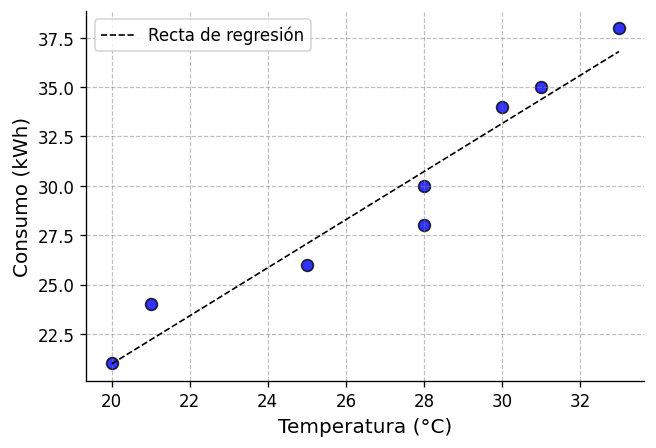

In [34]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, Y_estimado,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Temperatura (°C)', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Consumo (kWh)', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Leyenda
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)


Como puedes ver, la recta de regresión ajustada se aproxima bastante a los datos reales. Esto nos lleva al próximo punto.

## Coeficiente de determinación

El coeficiente de determinación se denota comúnmente como $R^2$ y tiene valores dentro del intervalo $0\le R^2\le1$. En el caso de la regresión lineal simple, este puede obtenerse elevando al cuadrado el coeficiente de correlación de Pearson.

Sin embargo, esta equivalencia no se mantiene en contextos más generales, como en la regresión múltiple u otros modelos. Por ello, es importante distinguir entre el coeficiente de correlación y el coeficiente de determinación.

$$R^2=\frac{\sum_{i=1}^{n} (\hat{Y}_i - \bar{Y})^2}{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}$$

Este cálculo del coeficiente de determinación es independiente del modelo y el tipo de regresión (lineal o no lineal).

In [38]:
R2 = ((Y_estimado - Y.mean())**2).sum() / ((Y - Y.mean())**2).sum()

print(f"El coeficiente de determinación es: {R2: 0.2%}")

El coeficiente de determinación es:  93.82%


A diferencia del coeficiente de correlación, el coeficiente de determinación sí puede interpretarse como un porcentaje. Este mide la proporción de la variabilidad de la variable dependiente que es explicada por el modelo.

En este caso, el resultado indica que el 93.82% de la variabilidad en $Y$ puede explicarse a partir de la variación en $X$. Dicho en otras palabras, el modelo logra capturar la mayor parte del comportamiento de la variable $Y$.

Es decir, el modelo explica gran parte de los cambios observados en $Y$, aunque aún existe una pequeña proporción de variabilidad que no es explicada y que se atribuye a otros factores.

## Supuestos

Para evaluar la confiabilidad del modelo de regresión, es necesario verificar ciertos supuestos a partir de los residuales. Recordemos que los residuales se calculan como:

$$ e = Y-\hat{Y}$$

Los residuales representan la diferencia entre los valores observados y los valores estimados por el modelo, y su análisis permite identificar posibles problemas en el ajuste.

Los principales supuestos del modelo son los siguientes:

+ **Independencia**: El error de una observación no debe afectar al error de otra observación. Por lo tanto, al hacer el gráfico de residuales no debe haber patrones predecibles. Los residuales deben ser ruido blanco, expresando así su naturaleza aleatoria. Una forma simple de detectar posible independencia es hacerse a uno mismo la pregunta ¿Tiene sentido que los datos tengan un orden específico? Si la respuesta es NO, entonces hay independencia.
+ **Linealidad**: La relación entre las variables debe ser aproximadamente lineal. Entonces, en el gráfico de residuales no debe haber tendencia (deben de ser horizontales). En el gráfico de dispersión sí se debe de observar un tendencia en línea recta.
+ **Normalidad**: Los errores deben distribuirse aproximadamente de manera normal. Esto significa que la mayoría de los errores deben ser pequeños, y los grandes poco frecuentes. En el gráfico de residuales, esto significa que la mayoría de los puntos deben de estar cerca de la recta de regresión, y los que están lejos de la recta deben de ser escasos.
+ **Homoscedasticidad**: La variabilidad de los errores debe ser constante. Los errores deben tener una dispersión similar en todos los valores de eje $X$.

Algunos de estos supuestos pueden validarse a golpe de vista o tras un análisis que queda a criterio del analista (independencia y linealidad), pero otros requerir pruebas estadísticas (normalidad y homoscedasticidad).

In [45]:
residuales = Y - Y_estimado

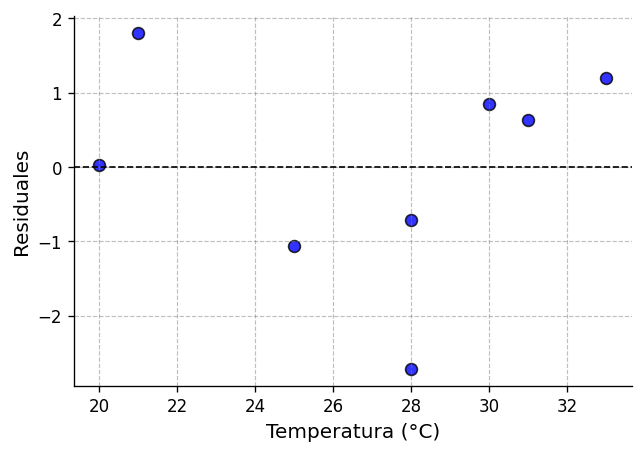

In [48]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Línea horizontal
plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Temperatura (°C)', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Residuales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)


En este caso, el orden de los datos no aporta información relevante al análisis; es decir, ordenar las observaciones por temperatura no introduce una estructura que aporte significado. Por ello, resulta razonable asumir la independencia entre las observaciones.

Por otra parte, los datos parecen ajustarse adecuadamente a la recta de regresión, lo que justifica el supuesto de linealidad.

Sin embargo, los supuestos de normalidad y homoscedasticidad no pueden evaluarse a golpe de vista, por lo que es necesario recurrir a pruebas estadísticas para verificar estos supuestos.

### Test de normalidad

Para evaluar el supuesto de normalidad, pueden emplearse distintos métodos según el tamaño de la muestra.

Cuando se cuenta con una cantidad considerable de datos ($n > 30$), una herramienta útil es el histograma. Si la distribución de los datos presenta una forma aproximadamente simétrica y acampanada, se puede considerar razonable asumir normalidad.

En el caso de muestras pequeñas ($n \leq 30$), es recomendable utilizar pruebas estadísticas formales, como la prueba de Shapiro–Wilk, la cual se basa en las siguientes hipótesis:

+ $H_0$: Los datos siguen una distribución normal
+ $H_1$: Los datos no siguen una distribución normal

Generalmente, se utiliza un nivel de significancia de $\alpha = 0.05$.

Una herramienta complementaria, útil para cualquier tamaño de muestra, es el gráfico cuantil–cuantil (Q-Q plot), en el cual se comparan los cuantiles teóricos de una distribución normal con los cuantiles observados en los datos. Si los puntos se alinean aproximadamente sobre una recta, se puede considerar que el supuesto de normalidad es razonable.

A continuación se muestra el código para las tres pruebas:

valor-p (Shapiro) = 0.7374221201066018


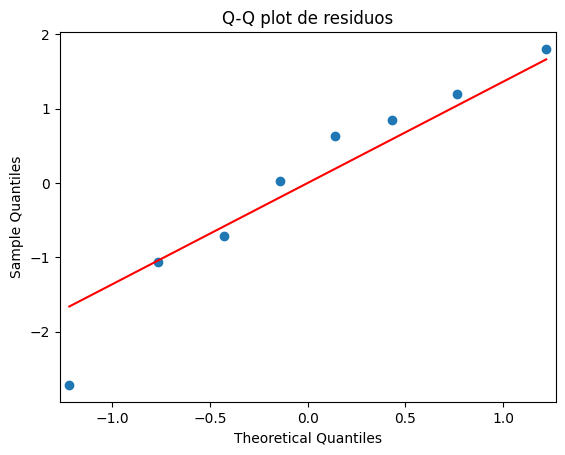

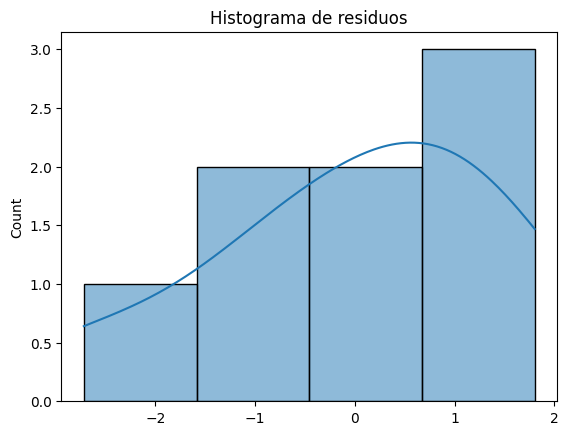

In [46]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Dado que la cantidad de datos es reducida ($n \le 30$) entonces nos fiamos del test de Shapiro, en el cual no se rechaza la hipótesis nula, por lo tanto se asume normalidad.

### Test de Breusch-Pagan (Homoscedasticidad)

El test de Breusch-Pagan nos ayuda a detectar homoscedasticidad a través de la evaluación de la heteroscedasticidad. Por lo que, si no hay heterocedasticidad, se puede asumir la homoscedasticidad.

+ $H_0$: No hay heterocedasticidad
+ $H_1$: Hay heterocedasticidad

También se puede usar $\alpha=0.05$ sin ningún problema.

In [49]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
x_constante = sm.add_constant(X)
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.9571



Con un valor-p tan alto, no se rechaza la hipótesis nula, por lo tanto se puede asumir homoscedasticidad.

## Conclusión

Al final se tiene un modelo que cumple con todos los supuestos, por lo que el modelo es confiable para predicción. Dados los datos:

| Temperatura (°C) | Consumo (kWh) |
|------------------|---------------|
| 20               | 21            |
| 21               | 24            |
| 25               | 26            |
| 28               | 28            |
| 28               | 30            |
| 30               | 34            |
| 31               | 35            |
| 33               | 38            |

El modelo puede tener un buen desempeño para interpolación (temperaturas entre 20 y 33 °C). Sin embargo, hay que ser muy conservadores al momento de realizar extrapolación (temperaturas fuera de los datos estudiados, menores a 20° o mayores a 33 °C).

Considerando el modelo obtenido:

$$\hat{Y}=-3.3618 + 1.2171 X$$

Si tenemos una temperatura de 22 °C el modelo predice:

$$\hat{Y}=-3.3618 + 1.2171 (22)\approx 23.41$$

un consumo de 23.41 kWh. Comparando los datos reales con los obtenidos con el modelo, se observa una buena precisión.

| Temperatura (°C) | Consumo (kWh) | Consumo predicho (kWh)|
|------------------|---------------|-----------------------|
| 20               | 21            |20.98                  |
| 21               | 24            |22.20                  |
| 25               | 26            |27.07                  |
| 28               | 28            |30.72                  |
| 28               | 30            |30.72                  |
| 30               | 34            |33.15                  |
| 31               | 35            |34.37                  |
| 33               | 38            |36.80                  |


No obstante, es importante señalar que, aunque el modelo presenta un buen ajuste, siempre existe una porción de la variabilidad que no es explicada por el mismo, la cual se atribuye a factores no considerados en el análisis.